# 12. CHRD-Bench Statistical Analysis

Bu notebook'ta gerçek Kapadokya görüntüleri ile Türkçe ve İngilizce istemlerden üretilen görüntüler karşılaştırılmaktadır.

Analizler;

- Cosine Similarity
- UMAP
- t-SNE
- Kültürel dağılım
- Görsel çeşitlilik
- Poster grafikleri

üzerinden gerçekleştirilmektedir.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

import umap.umap_ as umap

from sklearn.metrics.pairwise import cosine_similarity

## Embedding Dosyalarının Yüklenmesi

In [3]:
real = np.load("../embeddings/chrd_real_embeddings.npy")

tr = np.load("../embeddings/sdxl_tr_embeddings.npy")

en = np.load("../embeddings/sdxl_en_embeddings.npy")

print(real.shape)
print(tr.shape)
print(en.shape)

(82, 768)
(96, 768)
(96, 768)


## Ortalama Benzerlik Analizi

In [4]:
real_tr = cosine_similarity(real,tr)

real_en = cosine_similarity(real,en)

tr_en = cosine_similarity(tr,en)

print(real_tr.mean())

print(real_en.mean())

print(tr_en.mean())

0.3132833
0.35695267
0.422051


## En Yakın Komşu (Nearest Neighbor) Benzerliği

In [5]:
nearest_tr = real_tr.max(axis=1)

nearest_en = real_en.max(axis=1)

nearest_tr_en = tr_en.max(axis=1)

In [6]:
print("Nearest Real-TR :",nearest_tr.mean())

print("Nearest Real-EN :",nearest_en.mean())

print("Nearest TR-EN :",nearest_tr_en.mean())

Nearest Real-TR : 0.6112279
Nearest Real-EN : 0.5781631
Nearest TR-EN : 0.7509119


## Sonuçların Kaydedilmesi

In [7]:
results=pd.DataFrame({

"Metric":[

"Nearest Real-TR",

"Nearest Real-EN",

"Nearest TR-EN"

],

"Similarity":[

nearest_tr.mean(),

nearest_en.mean(),

nearest_tr_en.mean()

]

})

results

,Metric,Similarity
0,Nearest Real-TR,0.611228
1,Nearest Real-EN,0.578163
2,Nearest TR-EN,0.750912


In [8]:
results.to_csv(

"../logs/final_similarity.csv",

index=False
)

print("Kaydedildi.")

Kaydedildi.


## UMAP Görselleştirmesi

In [10]:
all_embeddings=np.vstack([

real,

tr,

en

])

labels=(

["Real"]*len(real)+

["TR"]*len(tr)+

["EN"]*len(en)

)

In [11]:
reducer=umap.UMAP(

n_neighbors=15,

min_dist=0.15,

metric="cosine",

random_state=42

)

embedding_2d=reducer.fit_transform(all_embeddings)

c:\CHRD_Project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
colors=[]

for l in labels:

    if l=="Real":

        colors.append("green")

    elif l=="TR":

        colors.append("blue")

    else:

        colors.append("red")

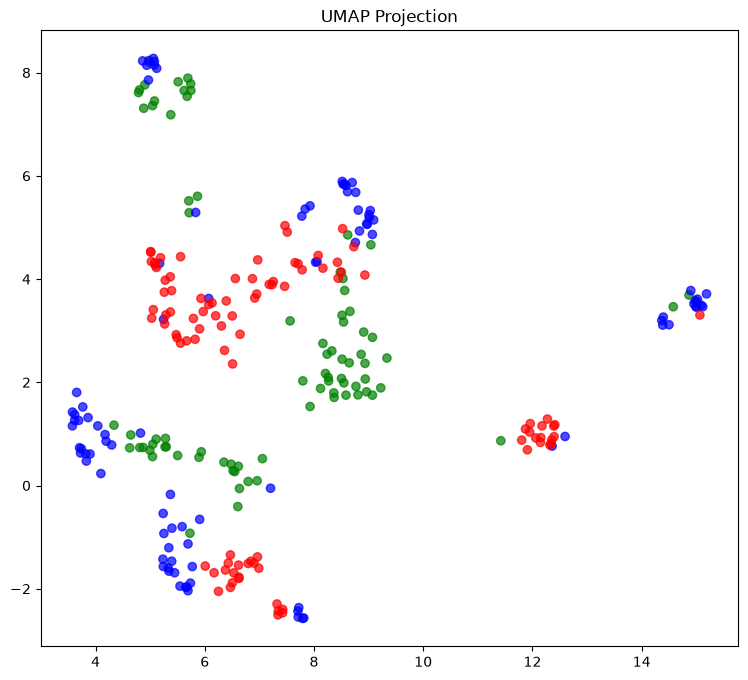

In [13]:
plt.figure(figsize=(9,8))

plt.scatter(

embedding_2d[:,0],

embedding_2d[:,1],

c=colors,

alpha=.7

)

plt.title("UMAP Projection")

plt.show()

## t-SNE Görselleştirmesi

In [14]:
tsne=TSNE(

n_components=2,

random_state=42,

perplexity=30

)

tsne_embedding=tsne.fit_transform(all_embeddings)

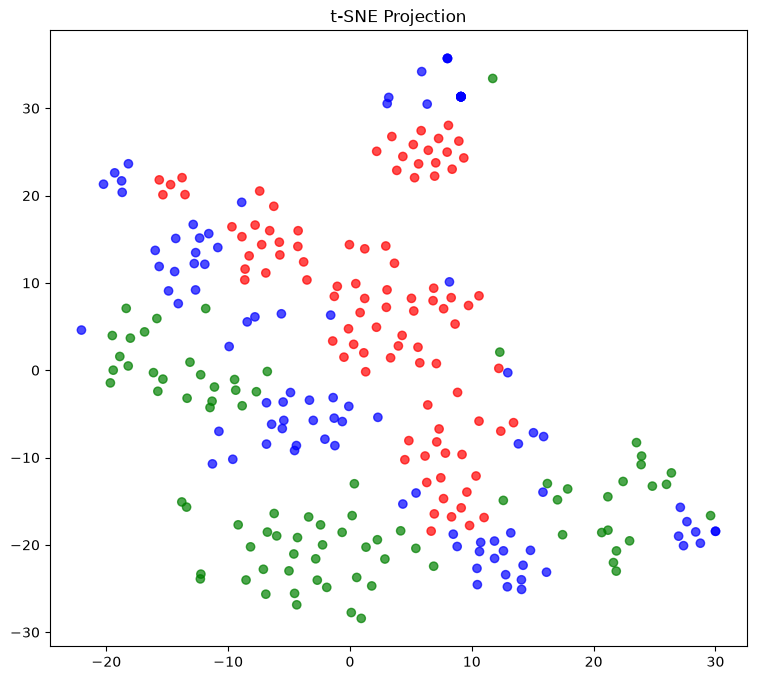

In [15]:
plt.figure(figsize=(9,8))

plt.scatter(

tsne_embedding[:,0],

tsne_embedding[:,1],

c=colors,

alpha=.7

)

plt.title("t-SNE Projection")

plt.show()

## Ortalama Benzerlik Grafiği

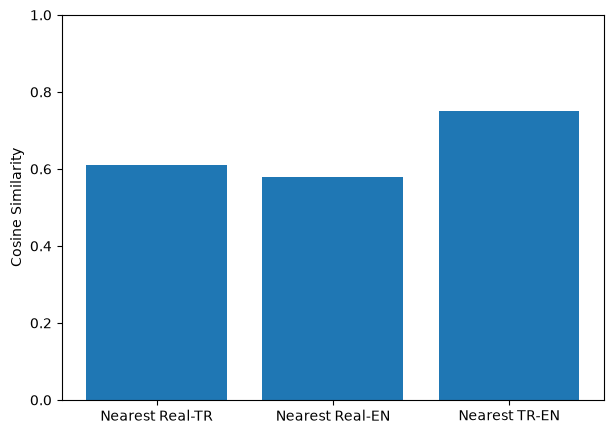

In [16]:
plt.figure(figsize=(7,5))

plt.bar(

results["Metric"],

results["Similarity"]

)

plt.ylim(0,1)

plt.ylabel("Cosine Similarity")

plt.show()

In [17]:
results.to_csv(

"../logs/final_analysis_results.csv",

index=False

)